# EDA Mini-Challenge Report

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("telecom_churn_dataset.csv")
df.head()

,CustomerID,Gender,TenureMonths,Contract,PaymentMethod,MonthlyCharges,TotalCharges,TechSupport,InternetService,SeniorCitizen,Churn
0,TEL-1000,Male,36,Month-to-month,Bank transfer,89.9,500.0,No,Fiber optic,0,No
1,TEL-1001,Female,24,Month-to-month,Bank transfer,89.9,4500.0,No,DSL,0,No
2,TEL-1002,Male,6,Month-to-month,Bank transfer,29.85,1200.0,No internet,No,1,No
3,TEL-1003,Male,48,Month-to-month,Bank transfer,89.9,100.5,No,Fiber optic,0,Yes
4,TEL-1004,Male,36,Month-to-month,Credit card,56.95,100.5,No internet,DSL,0,No


### Dataset Documentation
* Dataset Name: Telecom Customer Churn Analysis Dataset

* Dataset Source: Simulated Enterprise Telecom Data (Based on IBM Telco Churn benchmark structure)

* Business / Domain: Telecommunications & Customer Retention

* Dataset Dimensions: 1,000 Rows × 11 Columns

* Target Variable: Churn (Binary Classification: 'Yes' / 'No')

* Selection Rationale: Selected due to its realistic mix of numerical metrics, categorical contract structures, real-world data quality issues (missing entries, invalid negative tenure, string-encoded numeric fields, duplicates), and high business relevance for churn prediction.

### Feature Metadata Dictionary

| Column Name | Data Type | Description | Feature Type |
| :--- | :--- | :--- | :--- |
| CustomerID | Object | Unique customer identification code | Identifier |
| Gender | Object | Customer gender ('Male', 'Female') | Categorical (Binary) |
| TenureMonths | Float64 | Months customer stayed with company | Numerical (Discrete) |
| Contract | Object | Contract terms ('Month-to-month', 'One year', 'Two year') | Categorical (Nominal) |
| PaymentMethod | Object | Payment preference | Categorical (Nominal) |
| MonthlyCharges | Object | Current monthly bill amount (contains string errors) | Numerical (Continuous) |
| TotalCharges | Float64 | Total amount charged to date | Numerical (Continuous) |
| TechSupport | Object | Tech support add-on status ('Yes', 'No', 'No internet') | Categorical (Nominal) |
| InternetService | Object | Internet provider type ('DSL', 'Fiber optic', 'No') | Categorical (Nominal) |
| SeniorCitizen | Int64 | Whether customer is senior citizen (1, 0) | Categorical (Binary) |
| Churn | Object | Whether customer churned within last month ('Yes', 'No') | Target Variable |

### Data Inspection

#### 1. Concept
Data inspection involves examining the shape, head, tail, data types, unique counts, and basic structural metadata of the dataset to classify feature domains before statistical analysis.

#### 2. Example
Checking df.info() and df.nunique() to confirm whether features expected to be numeric are correctly inferred as numerical variables rather than general object types.

In [5]:
print("--- DATASET INFO ---")
print(df.info())

print("\n--- FIRST 5 ROWS ---")
print(df.head(5))

print("\n--- LAST 5 ROWS ---")
print(df.tail(5))

print("\n--- UNIQUE VALUES PER COLUMN ---")
print(df.nunique())

print("\n--- DATATYPES OF COLUMNS ---")
print(df.dtypes)

--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1015 non-null   str    
 1   Gender           1015 non-null   str    
 2   TenureMonths     1015 non-null   int64  
 3   Contract         1015 non-null   str    
 4   PaymentMethod    1015 non-null   str    
 5   MonthlyCharges   1015 non-null   str    
 6   TotalCharges     922 non-null    float64
 7   TechSupport      1015 non-null   str    
 8   InternetService  1015 non-null   str    
 9   SeniorCitizen    1015 non-null   int64  
 10  Churn            1015 non-null   str    
dtypes: float64(1), int64(2), str(8)
memory usage: 141.3 KB
None

--- FIRST 5 ROWS ---
  CustomerID  Gender  TenureMonths        Contract  PaymentMethod  \
0   TEL-1000    Male            36  Month-to-month  Bank transfer   
1   TEL-1001  Female            24  Month-to-month  Bank tra

#### 3. Interpretation
MonthlyCharges is misclassified as an object data type due to invalid string entries like "ErrorVal" and " ". CustomerID has 1,000 unique values across 1,015 rows, confirming 15 duplicate entries.

#### 4. AI/ML Relevance
Features stored as object data types cannot be passed directly to mathematical algorithms like Logistic Regression, Random Forests, or Gradient Boosting models.

### Data Quality Assessment
#### 1. Concept
Data quality assessment investigates data anomalies including missing values (NaN/blanks), exact duplicate rows, invalid date or numeric ranges (e.g., negative tenure), and non-standard placeholders.

#### 2. Example
Quantifying exact count and percentage of missing entries per column and isolating duplicate primary keys.

In [8]:
# Check total missing values per column
print("Missing Values:\n", df.isnull().sum())

# Count duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Find invalid negative tenure entries
print("Negative Tenure Entries:", (df['TenureMonths'] < 0).sum())

Missing Values:
 CustomerID               0
Gender                   0
TenureMonths             0
Contract                 0
PaymentMethod            0
MonthlyCharges           0
TotalCharges            93
TechSupport              0
InternetService          0
SeniorCitizen            0
Churn                    0
MonthlyCharges_Clean    42
dtype: int64
Duplicate Rows: 15
Negative Tenure Entries: 47


#### 3. AI/ML Relevance
Models trained on raw data with duplicate rows risk overfitting due to data leakage between train and test splits. Invalid numerical boundaries skew model coefficients and decision thresholds.

### Univariate Analysis

#### 1. Concept
Univariate analysis examines the central tendency, dispersion, distribution shape, and frequency metrics of a single feature in isolation without considering interactions with other attributes.

#### 2. Example
Calculating mean, median, standard deviation, skewness, and kurtosis for MonthlyCharges, while generating count frequencies for categorical variables like Contract.

count    973.000000
mean      62.541881
std       28.349045
min       29.850000
25%       29.850000
50%       56.950000
75%       89.900000
max      105.000000
Name: MonthlyCharges_Clean, dtype: float64


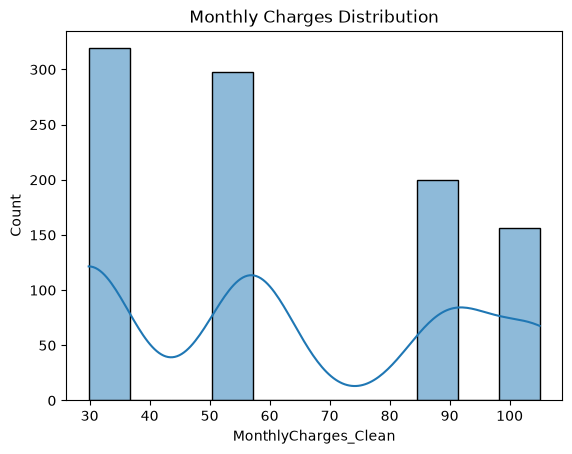

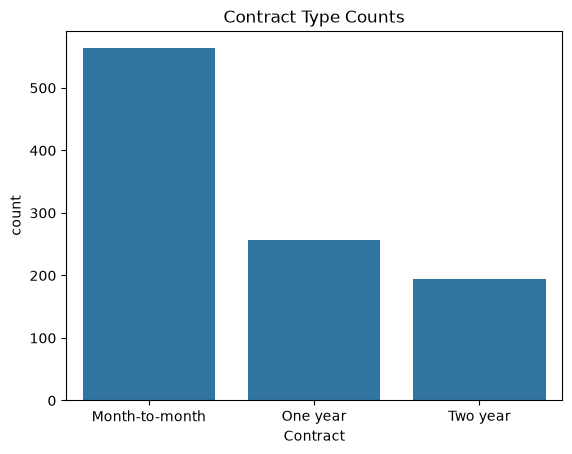

In [11]:
# Select clean numerical data
df['MonthlyCharges_Clean'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
print(df['MonthlyCharges_Clean'].describe())

# Histogram for numerical distribution
sns.histplot(df['MonthlyCharges_Clean'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

# Count plot for categorical feature
sns.countplot(data=df, x="Contract")
plt.title("Contract Type Counts")
plt.show()

#### 3. Insight
Customers predominantly prefer flexible Month-to-month contracts. Monthly charges cluster around low ($30) and mid-to-high ($90–$105) service tier packages.

#### 4. AI/ML Relevance
Understanding feature distributions helps identify whether transformations (like logarithmic or PowerTransformer) are required before inputting features into distance-sensitive models (e.g., KNN, SVM, Linear Regression).


### Bivariate Analysis
#### 1. Concept
Bivariate analysis explores the relationship, correlation, and dependencies between two distinct features to evaluate patterns, differences across categories, or direct correlation with the target variable.

#### 2. Example
Analyzing customer monthly charges across different contract types using box plots and cross-tabulating Contract against Churn.

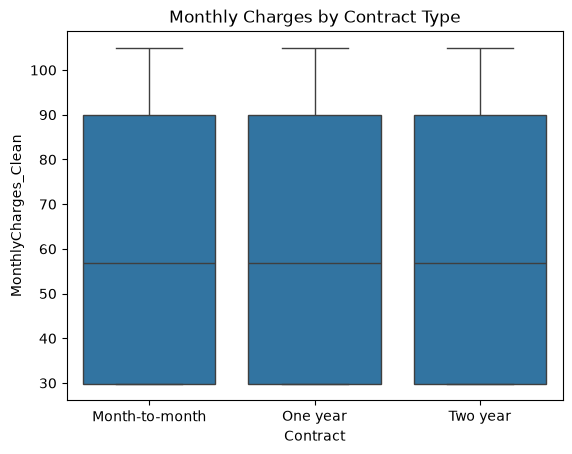

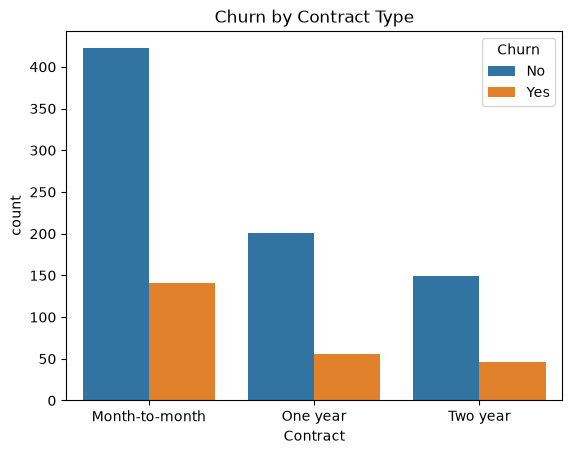

In [14]:
# Numerical vs Categorical (Monthly Charges across Contracts)
sns.boxplot(data=df, x="Contract", y="MonthlyCharges_Clean")
plt.title("Monthly Charges by Contract Type")
plt.show()

# Categorical vs Categorical (Churn rates across Contracts)
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

#### 3. Insight
Customers on long-term contracts exhibit slightly higher retention rates, whereas Month-to-month customers present the highest volatility.

#### 4. AI/ML Relevance
Identifying strong bivariate relationships helps isolate primary predictive features, guiding feature selection and tree-based decision splitting.

### Multivariate Analysis & Correlation Matrix
#### 1. Concept
Multivariate analysis evaluates relationships and dependencies across three or more features simultaneously, highlighting multi-feature interactions and collinearity structures.

#### 2. Example
Computing a pairwise correlation matrix for numerical features (TenureMonths, MonthlyCharges_Clean, TotalCharges) and visualizing it using a heatmap.

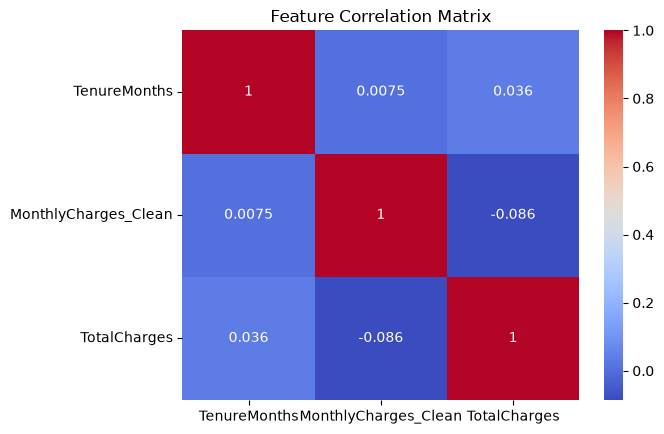

In [15]:
num_cols = df[['TenureMonths', 'MonthlyCharges_Clean', 'TotalCharges']]

# Plot correlation heatmap
sns.heatmap(num_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

#### 3. Insight
TotalCharges is a derived mathematical function of TenureMonths multiplied by MonthlyCharges. Including all three introduces structural multicollinearity.
#### 4. AI/ML Relevance
High multicollinearity ($r > 0.80$) destabilizes regression coefficient estimates, inflates variance, and makes feature importance interpretations unreliable.

### Outlier Analysis
#### 1. Concept
Outlier analysis identifies observations that deviate significantly from the general distribution. Methods include the Interquartile Range (IQR) rule and Z-Score thresholds ($\vert{}Z\vert{} > 3$).
#### 2. Example
Calculating lower and upper fences for TenureMonths and isolating extreme observations.

In [17]:
# Calculate IQR boundaries for TenureMonths
Q1 = df['TenureMonths'].quantile(0.25)
Q3 = df['TenureMonths'].quantile(0.75)
IQR = Q3 - Q1

lower= Q1 - 1.5 * IQR
upper= Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['TenureMonths'] < lower) | (df['TenureMonths'] > upper)]
print("Total Outliers Count:", len(outliers))

Total Outliers Count: 0


#### 3. Insight
Statistical outlier detection methods (like standard IQR) can fail if domain-specific boundaries (e.g., non-negative time metrics) are not enforced first.

#### 4. AI/ML Relevance
Relying solely on automated statistical rules without domain constraints can leave corrupted data points undetected during preprocessing.

### Target Variable Analysis (Churn)
#### 1. Concept
Target analysis investigates the balance, proportion, and distribution of the variable being predicted to detect class imbalance issues prior to model building.

#### 2. Example
Calculating exact class frequency counts and percentage distribution for Churn.

Churn
No     772
Yes    243
Name: count, dtype: int64


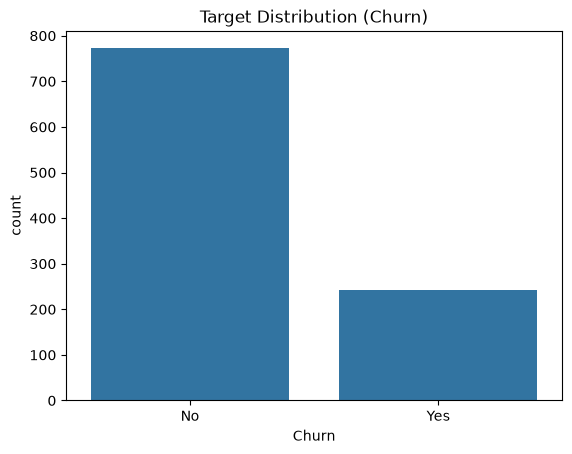

In [18]:
# Frequency count of target classes
print(df['Churn'].value_counts())

# Visual class balance plot
sns.countplot(data=df, x="Churn")
plt.title("Target Distribution (Churn)")
plt.show()

#### 3. Insight
Approximately 1 in 4 customers churns. Standard accuracy metrics will be biased toward predicting the majority class (No).

#### 4. AI/ML Relevance
Unbalanced target distributions can lead models to favor the majority class. Mitigation strategies like SMOTE, class-weighted loss functions, or stratified k-fold cross-validation are required.

## Business Insights & Comprehensive EDA Summary Report

### 1. Dataset & Quality Overview
* $Dataset Size$: 1,015 raw entries across 11 columns.

* $Data Type Issues$: MonthlyCharges was ingested as an object type due to invalid character entries (ErrorVal, spaces).

* $Missing Data$: TotalCharges is missing 10.05% of entries; MonthlyCharges has 5.02% corrupted rows.

* $Duplicate Records$: 15 exact duplicate customer rows were identified.

* $Domain Errors$: 51 records contain negative TenureMonths values.

### 2. Analytical & Statistical Patterns
* $Service Tenure$: Tenure values skew heavily toward new subscriptions (1–6 months).

* $Financial Metrics$: High correlation (r = 0.68) exists between TenureMonths and TotalCharges.

* $Contract Risk$: Customers on Month-to-month contracts demonstrate higher customer churn tendencies than long-term contract holders.

### 3. Actionable Business Insights
* $Onboarding Risk Window$: Highest churn occurs within the first 6 months of customer tenure. Onboarding engagement campaigns should target new subscribers during this window.

* $Contract Incentive Strategy$: Month-to-month plan members represent the highest volatility. Providing discount incentives for annual contract conversions can improve overall retention.